# Course 1 from Scratch: Regression and Classification in Pure NumPy

| Course idea | Where here |
|---|---|
| Univariate linear regression + squared error cost | `2` |
| Gradient descent, learning curves, learning-rate choice | `3` |
| Vectorization (loop vs `np.dot`) | `4` |
| Multiple linear regression + z-score feature scaling | `5` |
| Feature engineering & polynomial regression | `6` |
| Logistic regression: sigmoid, log loss, GD, decision boundary | `7` |
| Overfitting + regularization (linear & logistic) | `8` |


**Tasks:** 
* *Regression* — predict campaign **revenue**. 
* *Classification* — predict whether a campaign hits **ROAS ≥ 4** (a common target ROAS).

In [5]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt  
import time  

from pathlib import Path


plt.rcParams['figure.dpi'] = 90 
rng = np.random.default_rng(42)

In [7]:
def repo_root(marker: str = "data") -> Path:
    """Walk up from the CWD until we find the folder containing `data/`."""
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not locate a parent containing '{marker}/'")

 
DATA_PATH = repo_root() / "data" / "global_ads_performance_dataset.csv"
print(DATA_PATH)

D:\Projects\AI and ML\Global Ads Performance - Study Case\rosetta-ml\data\global_ads_performance_dataset.csv


In [8]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
print(df.shape)
print(df.head())

(1800, 14)
        date    platform campaign_type    industry  country  impressions  \
0 2024-01-21  Google Ads        Search     Fintech      UAE        59886   
1 2024-01-22  TikTok Ads        Search      EdTech       UK       135608   
2 2024-06-15  TikTok Ads         Video  Healthcare      USA        92313   
3 2024-01-02  TikTok Ads      Shopping        SaaS  Germany        83953   
4 2024-02-22  TikTok Ads        Search  Healthcare       UK        91807   

   clicks     CTR   CPC  ad_spend  conversions    CPA   revenue   ROAS  
0    2113  0.0353  1.26   2662.38          159  16.74   4803.43   1.80  
1    5220  0.0385  1.18   6159.60          411  14.99  64126.68  10.41  
2    5991  0.0649  0.85   5092.35          267  19.07  10489.07   2.06  
3    5935  0.0707  1.32   7834.20          296  26.47  50505.07   6.45  
4    4489  0.0489  1.93   8663.77          107  80.97   3369.53   0.39  


**--- manual train/test split (80/20) ---**


In [10]:
# shuffle the row positions
# len(df) is 1800. rng.permutation(1800) returns an array containing every integer 0–1799 exactly once, in random order. 
idx = rng.permutation(len(df)); 

# find the cut point
cut = int(.8 * len(df)) # 0.8 * 1800 = 1440

train, test = df.iloc[idx[:cut]].copy(), df.iloc[idx[cut:]].copy() 
print(f'train m = {len(train)}')
print(f'test m = {len(test)}') 

train m = 1440
test m = 360


## 2. Univariate Linear Regression: `f(x) = wx + b`

Predict **revenue** from **ad_spend** alone. We will use the squared error cost 
>$J(w,b) = \frac{1}{2m}\sum_i (f_{w,b}(x^{(i)}) - y^{(i)})^2$

We work in scaled units (spend in $1k, revenue in $1k) so the numbers are readable. 

In [12]:
x_tr = train.ad_spend.values / 1000
y_tr = train.revenue.values / 1000 

x_te = test.ad_spend.values / 1000 
y_te = test.revenue.values / 1000 

def f_uni(x, w, b): 
       return w*x + b 

def cost_uni(x, y, w, b): 
    m = len(x)
    return np.sum((f_uni(x, w, b) - y)**2) / (2*m)

print('cost at w = 0, b = 0: ', round(cost_uni(x_tr, y_tr, 0, 0) , 2))
print('cost at w = 3, b = 10: ', round(cost_uni(x_tr, y_tr, 3, 10) , 2))



cost at w = 0, b = 0:  1074.41
cost at w = 3, b = 10:  468.46


minimum on grid:  w = 3.0808   J = 468.3002


Text(0, 0.5, 'J(w, b=10)')

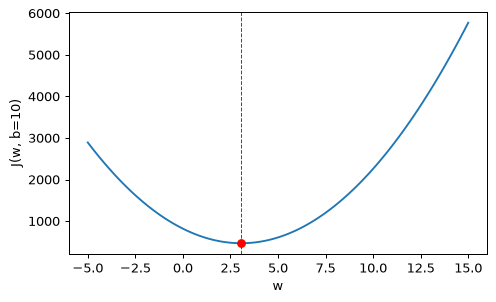

In [21]:
# Visualize J(w) with b fixed, the convex 'soup bowl'  
b_fixed = 10
ws = np.linspace(-5, 15, 100)
Js = np.array([cost_uni(x_tr, y_tr, w, b_fixed) for w in ws])   # keep the values

i = Js.argmin()
w_best, J_best = ws[i], Js[i]
print(f'minimum on grid:  w = {w_best:.4f}   J = {J_best:,.4f}')


if i in (0, len(ws) - 1):
    print('WARNING: minimum sits at the edge of ws — widen the range')

plt.figure(figsize=(6, 3.5))
plt.plot(ws, Js)
plt.plot(w_best, J_best, 'ro', label=f'min: w={w_best:.2f}, J={J_best:,.0f}')
plt.axvline(w_best, ls='--', lw=0.8, color='r')
plt.xlabel('w')
plt.ylabel(f'J(w, b={b_fixed})')